# Ballon d'Or 2025 Nominees' Performance Analysis

## Project Overview
This project explore the performance statistics of the 2025 Ballon d'Or Nominees using Python, Pandas, Matplotlib. The analysis examines the players' demographics, playing time, league-level statistics, and the relationship between their expected goals and actual goals.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

### Dataset

In [18]:
# Import the data and print the first 5 rows
datadir = "DATA 200 - Project 1 - Khang Ho"
file = os.path.join(datadir, "ballondor_2025_nominees_dataset.csv")
df = pd.read_csv(file)
print(df.head(5))

    Rk               Player   Nation    Pos      Squad  Age  Born  MP  Starts  \
0  228        Achraf Hakimi   ma MAR     DF  Paris S-G   25  1998  25      24   
1  319  Alexis Mac Allister   ar ARG     MF  Liverpool   25  1998  35      30   
2  408          Cole Palmer  eng ENG  MF,FW    Chelsea   22  2002  37      36   
3  435          Declan Rice  eng ENG     MF    Arsenal   25  1999  35      33   
4  180      Denzel Dumfries   nl NED  DF,FW      Inter   28  1996  29      20   

    Min  ...  AstPer90  G+APer90  G-PKPer90  G+A-PKPer90  xGPer90  xAGPer90  \
0  2066  ...      0.26      0.44       0.17         0.44     0.13      0.27   
1  2599  ...      0.17      0.35       0.17         0.35     0.10      0.16   
2  3191  ...      0.23      0.65       0.31         0.54     0.49      0.31   
3  2825  ...      0.22      0.35       0.13         0.35     0.11      0.21   
4  1955  ...      0.09      0.41       0.32         0.41     0.25      0.15   

   xG+xAGPer90  npxGPer90  npxG+xAGPer

### Data Exploration

In [19]:
# General information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rk             30 non-null     int64  
 1   Player         30 non-null     object 
 2   Nation         30 non-null     object 
 3   Pos            30 non-null     object 
 4   Squad          30 non-null     object 
 5   Age            30 non-null     int64  
 6   Born           30 non-null     int64  
 7   MP             30 non-null     int64  
 8   Starts         30 non-null     int64  
 9   Min            30 non-null     int64  
 10  90s            30 non-null     float64
 11  Gls            30 non-null     int64  
 12  Ast            30 non-null     int64  
 13  G+A            30 non-null     int64  
 14  G-PK           30 non-null     int64  
 15  PK             30 non-null     int64  
 16  PKatt          30 non-null     int64  
 17  CrdY           30 non-null     int64  
 18  CrdR        

In [20]:
# A set of descriptive statistics for the data
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,GlsPer90,AstPer90,G+APer90,G-PKPer90,G+A-PKPer90,xGPer90,xAGPer90,xG+xAGPer90,npxGPer90,npxG+xAGPer90
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,329.300000,25.000000,1998.633333,29.900000,26.533333,2330.166667,25.890000,12.133333,5.800000,17.933333,...,0.438000,0.219667,0.658333,0.372000,0.592333,0.405333,0.228000,0.632000,0.345333,0.572000
std,130.080651,4.177113,4.238439,7.680472,8.471996,736.752898,8.189453,10.444379,4.389643,12.500851,...,0.341088,0.148683,0.398143,0.267574,0.330712,0.290169,0.138872,0.340926,0.231944,0.292379
min,80.000000,17.000000,1988.000000,2.000000,0.000000,19.000000,0.200000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.750000,22.000000,1996.000000,29.000000,20.500000,1976.750000,21.950000,4.000000,3.000000,9.000000,...,0.170000,0.102500,0.365000,0.155000,0.365000,0.150000,0.140000,0.332500,0.135000,0.332500
50%,333.000000,25.000000,1998.500000,31.000000,29.000000,2526.000000,28.050000,9.000000,5.000000,15.500000,...,0.375000,0.220000,0.615000,0.310000,0.560000,0.325000,0.220000,0.625000,0.315000,0.580000
75%,428.250000,27.000000,2001.750000,34.750000,32.000000,2835.500000,31.475000,20.250000,8.000000,26.500000,...,0.682500,0.305000,0.867500,0.525000,0.785000,0.655000,0.302500,0.900000,0.497500,0.807500
max,595.000000,35.000000,2007.000000,38.000000,38.000000,3371.000000,37.500000,39.000000,18.000000,47.000000,...,1.250000,0.580000,1.480000,1.040000,1.350000,0.990000,0.480000,1.290000,0.820000,1.250000


### League-level Analysis

In [21]:
# Group the data based upon a variable and calculate 3 different aggregations
groupdata = df.groupby("League")["Min"].agg(["sum", "median", "max"])
print(groupdata.sort_values("sum", ascending = False))

                  sum  median   max
League                             
Premier League  18071  2825.0  3371
La Liga         16636  2847.5  2907
Ligue 1         14095  1787.0  2091
Bundesliga       9664  2366.0  2598
Serie A          8635  2259.5  2938
Primeira Liga    2804  2804.0  2804


The agregations of the data suggest that: 
- Premier League has the highest total number and also highest maximum number of minutes played by the nominees from the League.
- La Liga does not have the highest total minutues and maximum number of minutes played by the nominees, but it has the highest median, indicating the nominees from the Spanish League are the most consistent players.
- Primeira Liga has the same value through 3 aggregations, indicating that there is only one nominee coming from the Portugese League.

### Visualization

#### Age Distribution

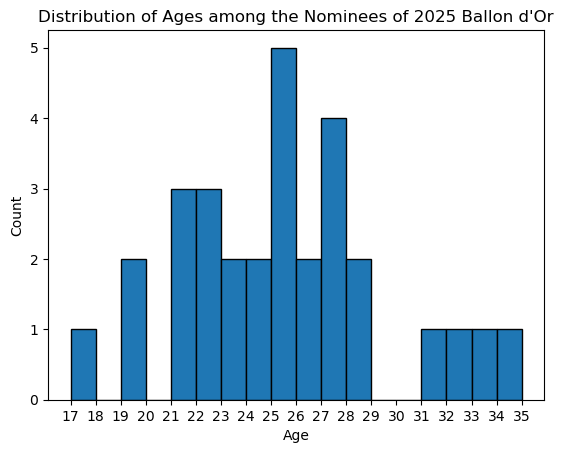

In [22]:
# Histogram
plt.hist(df["Age"], bins = range(17, 36), edgecolor = "black")
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Ages among the Nominees of 2025 Ballon d'Or")
plt.xticks(range(17, 36))
plt.show()

- The histogram shows the range of ages among the nominees for the 2025 Ballon d'Or, with the youngest being 17 years old and the oldest 35.
- It can also be observed that age 25 is the most common among the nominees, and the 25–27 age range seems to be the “golden period” for soccer players, as they often reach their peak performance and achieve their best results during these years of age.

#### Playing time

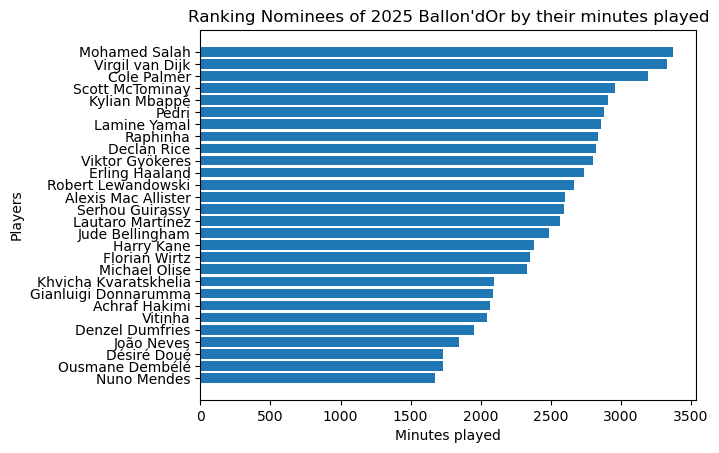

In [53]:
# Horizontal bar chart
## Because the data includes the players transferred in mid-season as 2 observations each for such players, one for the former club and one for the 
### current club, I have to sum up the total minutes played by them in both clubs during the season
df_minutes_sum = df.groupby("Player")["Min"].sum()
df_min_sorted = df_minutes_sum.sort_values(ascending = True)
plt.barh(df_min_sorted.index, df_min_sorted.values)
plt.xlabel("Minutes played")
plt.ylabel("Players")
plt.title("Ranking Nominees of 2025 Ballon'dOr by their minutes played")
plt.show()

- The horizontal bar chart shows that Mohamed Salah has the highest number of minutes played, while Nuno Mendes has the fewest among all nominees.
- Ousmane Dembélé, the winner of the 2025 Ballon d’Or, has the second lowest number of minutes played, which is a particularly interesting observation from the chart.

#### Players' Expected Goals vs. Actual Goals

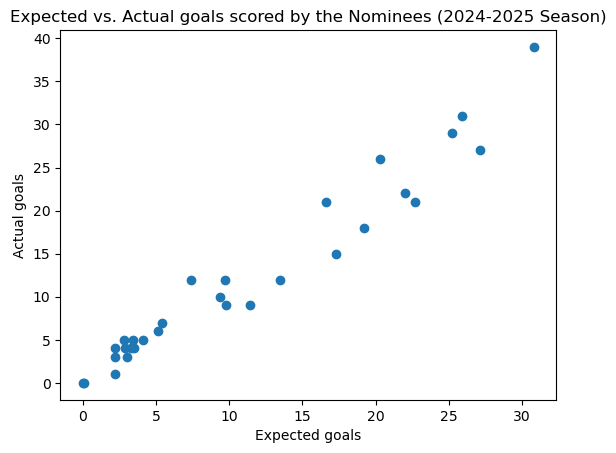

In [60]:
# Scatterplot of relationship between xG and Gls
plt.scatter(df["xG"], df["Gls"])
plt.xlabel("Expected goals")
plt.ylabel("Actual goals")
plt.title("Expected vs. Actual goals scored by the Nominees (2024-2025 Season)")
plt.show()

### Interpretation
The scatterplot illustrates a strong positive linear relationship between expected goals and actual goals scored among the 2025 Ballon d’Or Nominees during the 2024–2025 season. As the expected number of goals increases from around 0 to nearly 30, the actual goals rise proportionally, forming a tight, upward-sloping trend that reflects a clear connection between chance quality and finishing output. This indicates that, overall, players who consistently create or receive high-quality opportunities tend to convert them effectively into goals.

Notably, several standout forwards slightly exceed the general trendline, suggesting superior finishing ability. Viktor Gyökeres, for instance, records an impressive 39 goals compared to 30.8 expected goals, demonstrating outstanding efficiency in front of goal. Robert Lewandowski also outperforms expectations with 27 goals from 27.1 expected goals, maintaining an elite level of precision. Meanwhile, players such as Erling Haaland (22 goals, 22.0 expected goals) and Kylian Mbappé (31 goals, 25.9 expected goals) reflect strong alignment between expected and actual outcomes, showing reliable conversion of high-quality chances.

Outliers are minimal, with only one nominee scoring more than 35 goals against roughly 30 expected goals, possibly Gyökeres, highlighting exceptional consistency rather than luck. 

In contrast, several midfielders and defenders remain clustered at the lower-left corner of the chart, where both expected and actual goals are under five, aligning with their defensive or supportive roles on the pitch.

Overall, the scatterplot validates the expected goals metric as a reliable and meaningful indicator of goal-scoring performance, showing that success among these elite players depends primarily on skills and opportunities quality rather than randomness or luck.

### Evaluation and next step
The observed relationship between expected and actual goals appears to be strong and consistent, suggesting that the expected goals metric reliably reflects scoring performance among elite players. The scatterplot shows a clear upward trend with only one outlier, reinforcing that players who generate high-quality chances tend to convert them effectively. However, because this analysis is based only on the 2025 Ballon d’Or Nominees, it may reflect some kind of bias, as top performers naturally display less variation in finishing ability.

To make this hypothesis more credible, further testing is needed using a larger dataset across multiple seasons and player levels. Conducting correlation analysis could quanlify the relationship’s strength and significance, while controlling for factors such as position, minutes played, injuries, and team quality would help isolate its true effect. Extending the study to predictive modeling would also be potential to determine whether expected goals can credibly forecast future scoring performance.

### Additional information needed
To enhance this analysis, additional data on shot locations, team strength, club's position and assist contributions would be valuable. Including data from multiple seasons and leagues could also help test whether the relationship between expected and actual goals remains consistent across different contexts. Information on players’ shot accuracy, conversion rates, and injuries could also clarify performance variations. Combining these variables would allow for more comprehensive modeling and a stronger understanding of how expected goals interact with tactical roles, opportunity quality, and overall player efficiency in determining scoring outcomes.